### Analyze Clustering

In [1]:
import json, os, sys, glob

In [2]:
json_list_file = 'best_model_list_X013-2.txt'

with open(json_list_file, 'r') as f:
    json_files = [line[:-1] if line.endswith('\n') else line for line in f.readlines()]

In [3]:
def lines_no_newlines(filename):
    with open(filename, 'r') as f:
        return [line[:-1] if line.endswith('\n') else line for line in f.readlines()]

def parse_clustering_log(json_fn):
    #Unpack json
    with open(json_fn, 'r') as g:
        json_params = json.load(g)
    
    #Determine the location of the save_dir from the json file
    model_name = json_params["model_name"]
    n_latents = json_params["latent_dim"]
    test_slice = json_params["test_slice"]
    data_dir = os.path.join(json_params["save_dir"], f'{model_name}/', f'{n_latents:04d}_latents/', f'rpt_{test_slice}/')

    lines = lines_no_newlines(os.path.join(data_dir, 'clustering', 'clustering_metric_log.txt'))
    i = 18
    kmeans = lines[i:i+2], lines[i+4:i+6], lines[i+8:i+10], lines[i+12:i+14], lines[i+16:i+18], lines[i+20:i+22]
    i = 42
    aggl = lines[i:i+2], lines[i+4:i+6], lines[i+8:i+10], lines[i+12:i+14], lines[i+16:i+18], lines[i+20:i+22]
    i=66
    hdbs = lines[i:i+2], lines[i+4:i+6], lines[i+8:i+10], lines[i+12:i+14], lines[i+16:i+18], lines[i+20:i+22]

    #Parse these to actual numbers
    # in order [rand ... (VAE, VAE_err, PCA, PCA_err)
    kmeans = [(float(elem[1].split(' ')[-3]),
               float(elem[1].split(' ')[-1]),
               float(elem[0].split(' ')[-3]),
               float(elem[0].split(' ')[-1])) for elem in kmeans]
    
    aggl = [(float(elem[1].split(' ')[-3]),
               float(elem[1].split(' ')[-1]),
               float(elem[0].split(' ')[-3]),
               float(elem[0].split(' ')[-1])) for elem in aggl]
    
    hdbs = [(float(elem[1].split(' ')[-3]),
               float(elem[1].split(' ')[-1]),
               float(elem[0].split(' ')[-3]),
               float(elem[0].split(' ')[-1])) for elem in hdbs]
    
    return kmeans, aggl, hdbs

In [4]:
import matplotlib.pyplot as plt
title_key = ['Rand Score',
             'Normalized MI Score',
             'Fowlkes-Mallows Score',
             'Silhouette Score',
             'Davies-Bouldin Score',
             'Calinski-Harabasz Score']

def plot_metric(metric, latents, title=None, method=0, show=False):
    """
    method=0 for kmeans, 1 for agglomerative, 2 for hdbscan
    """
    vae_val = [data[method][0] for data in metric]
    vae_err = [data[method][1] for data in metric]
    pca_val = [data[method][2] for data in metric]
    pca_err = [data[method][3] for data in metric]
    #print(vae_val, vae_err, pca_val, pca_err)

    plt.clf()
    plt.errorbar(x=latents, y=vae_val, yerr=vae_err, label='VAE')
    plt.errorbar(x=latents, y=pca_val, yerr=pca_err, label='PCA')
    if title is not None:
        plt.title(title)
    plt.xlabel('Num Latent/Component')
    plt.ylabel('Clustering Metric Value')
    if title is not None and 'Calinski' in title:
        plt.yscale('log')
    plt.xscale('log')
    plt.legend()
    if show:
        plt.show()
    else:
        plt.close()

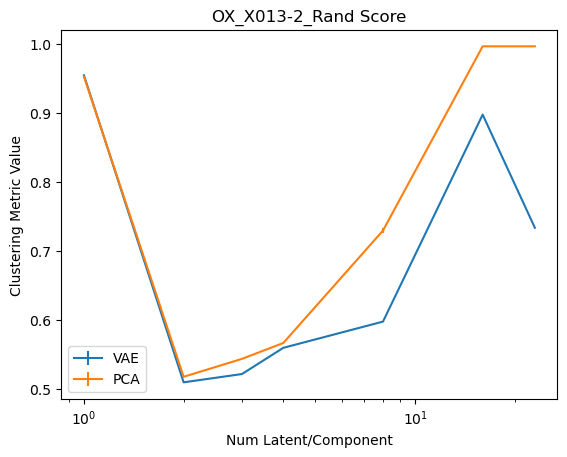

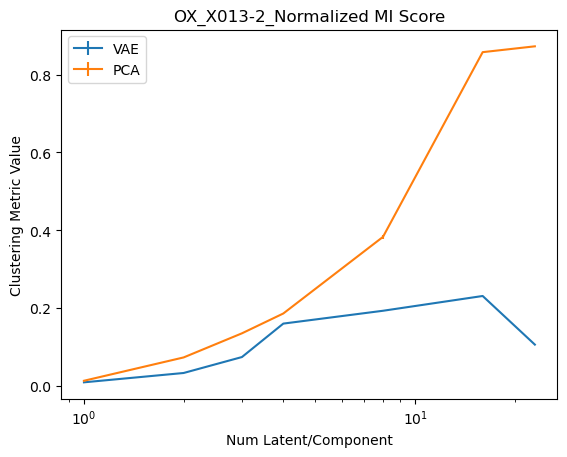

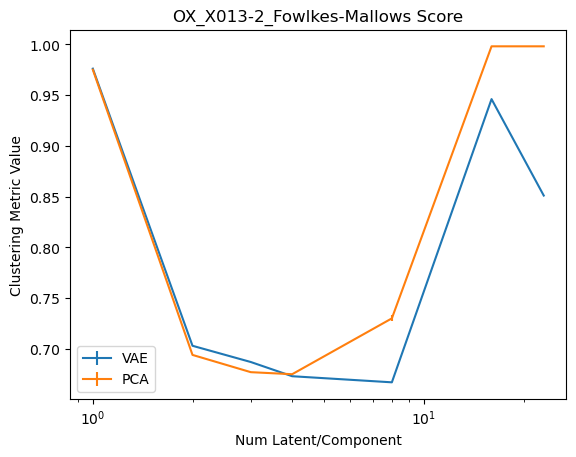

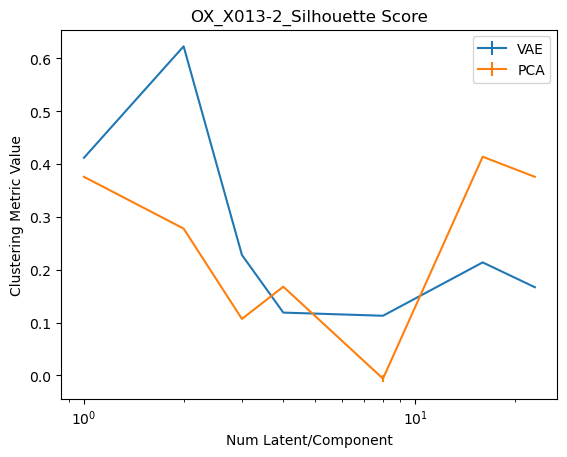

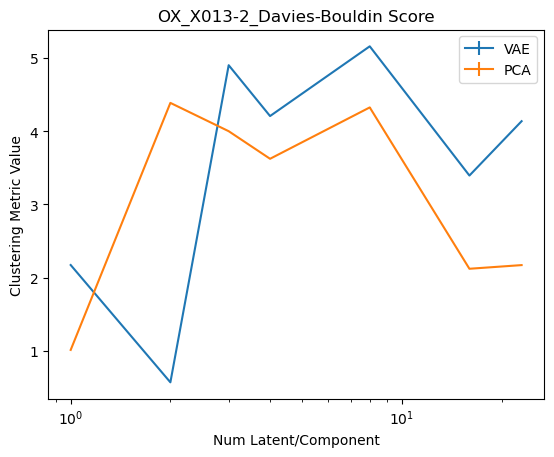

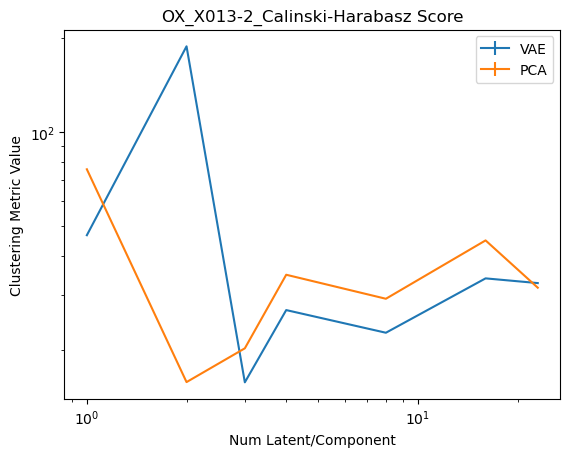

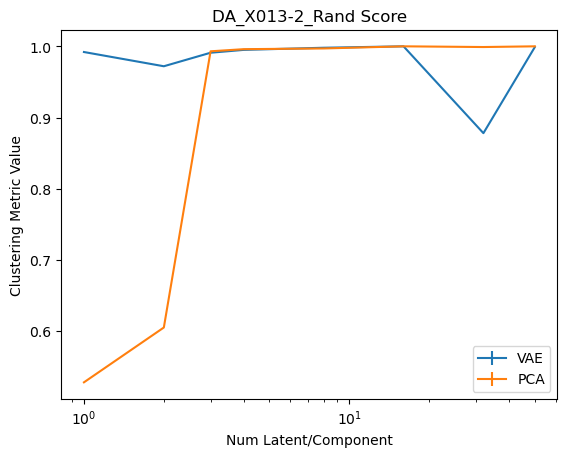

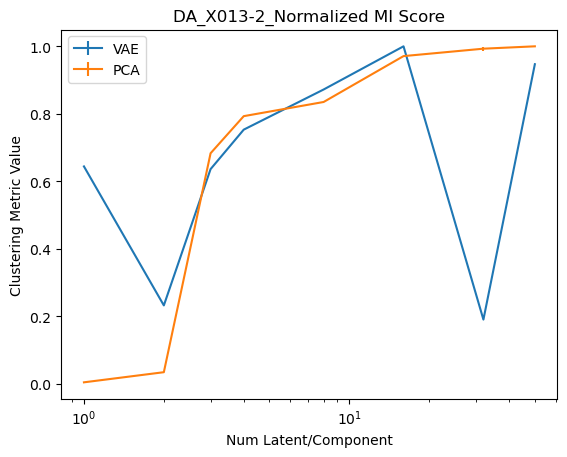

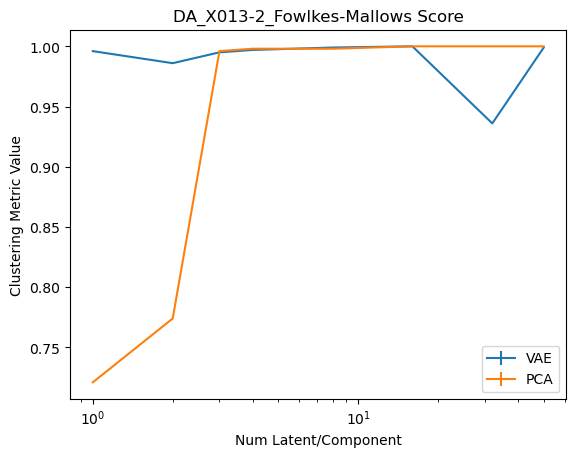

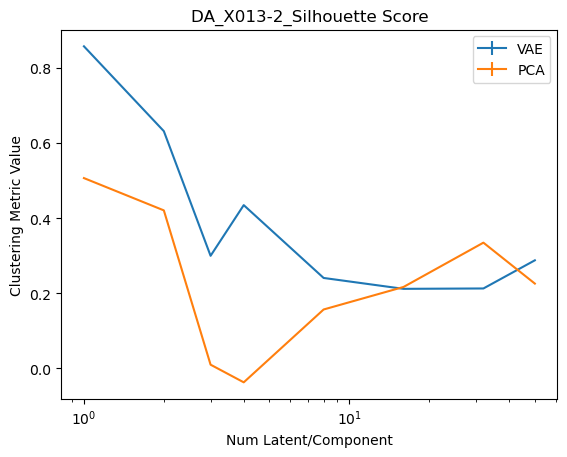

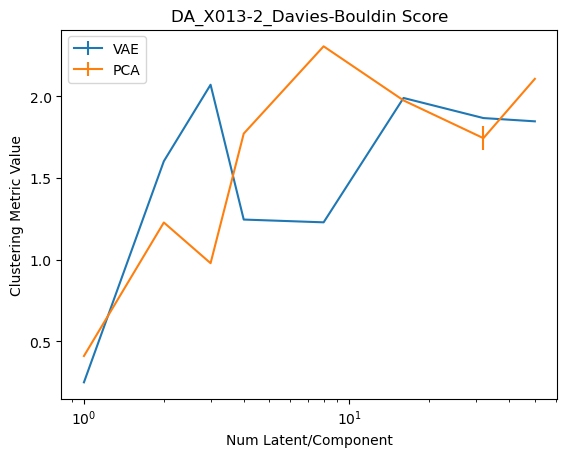

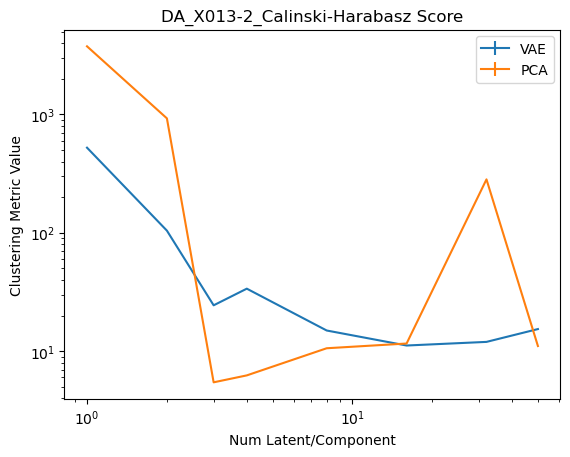

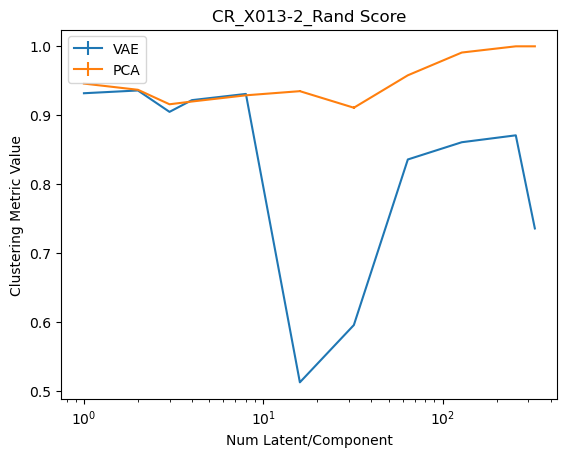

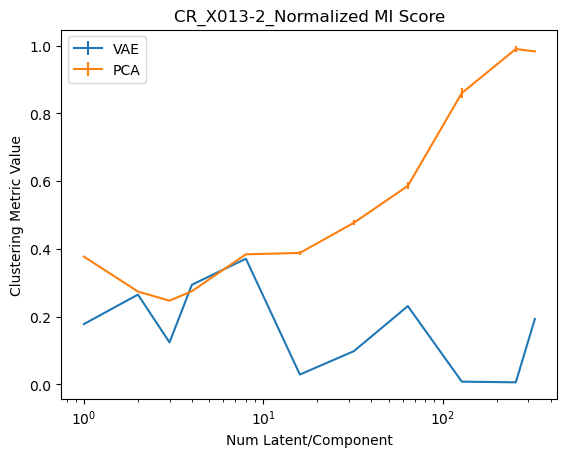

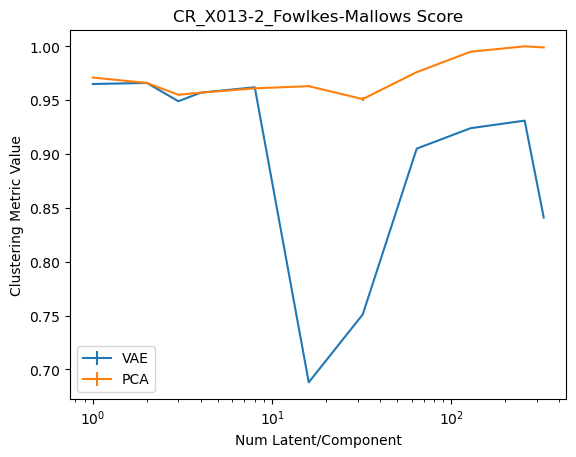

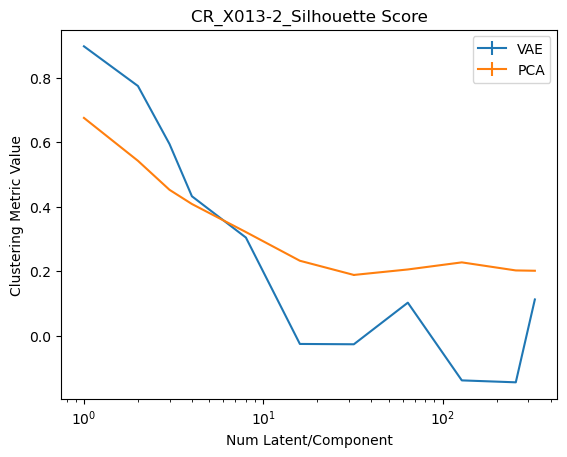

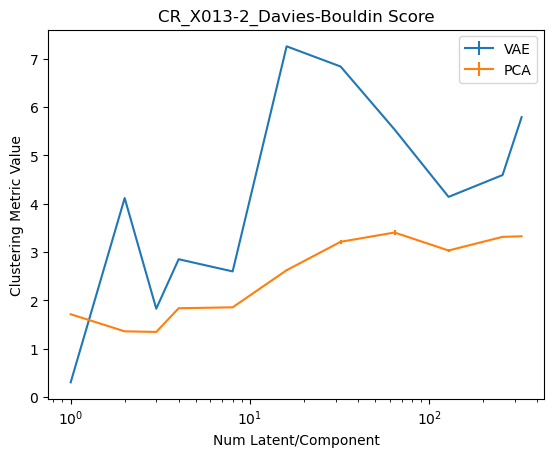

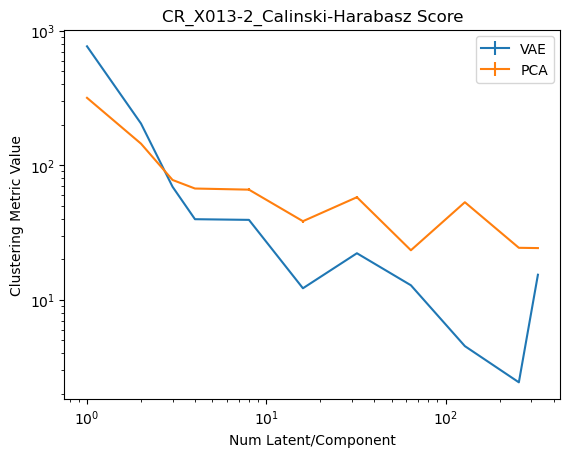

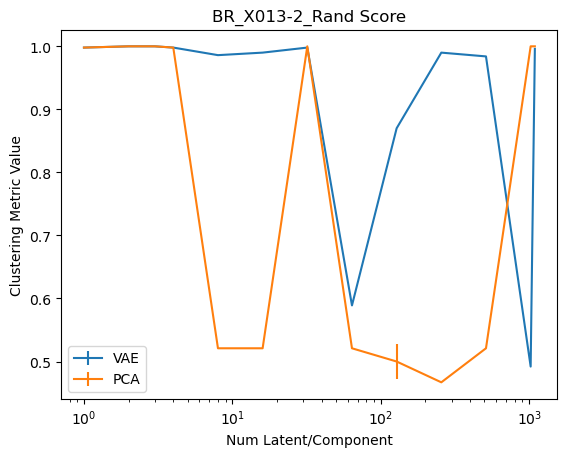

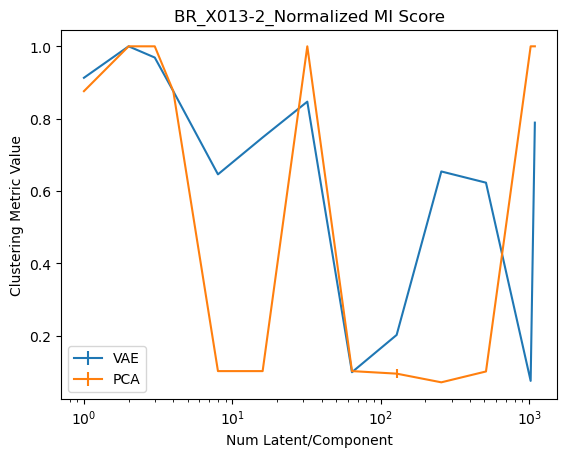

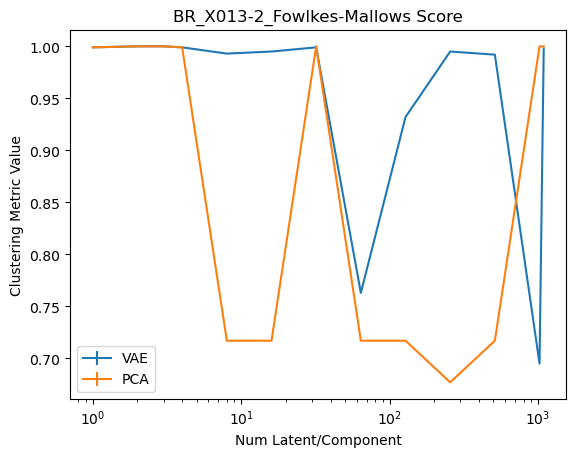

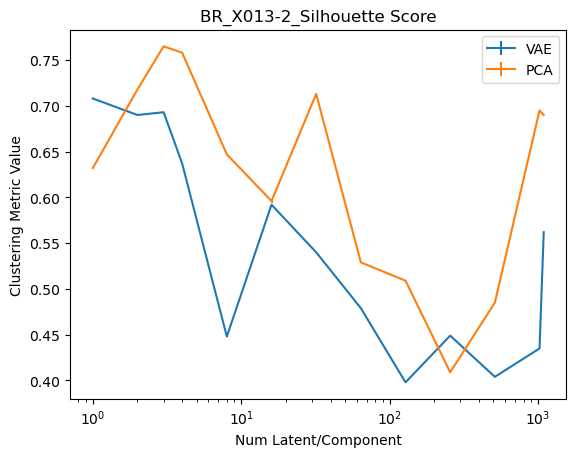

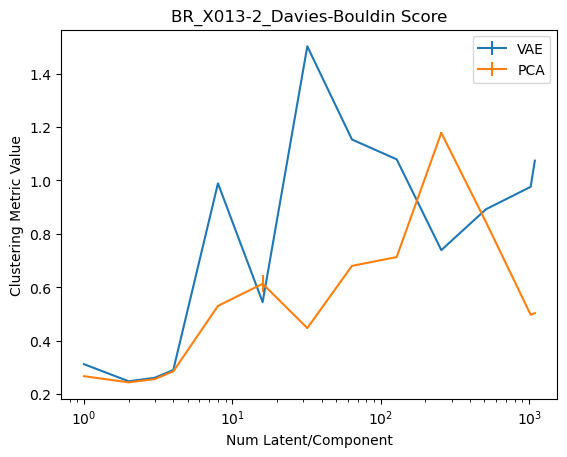

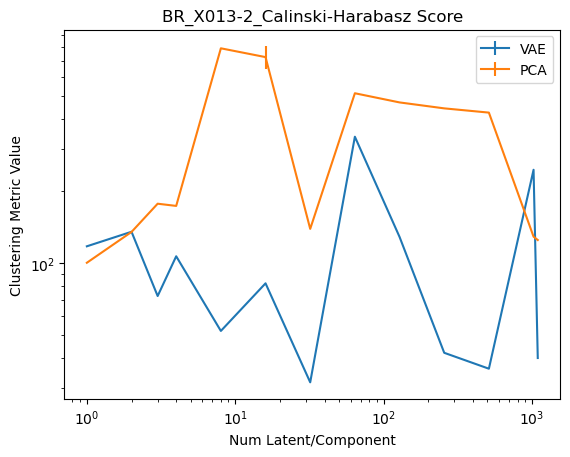

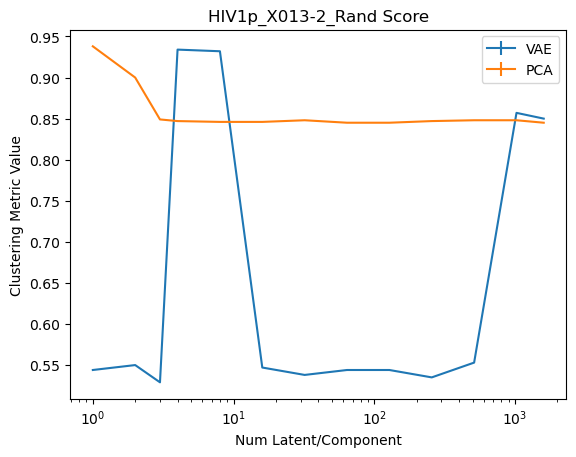

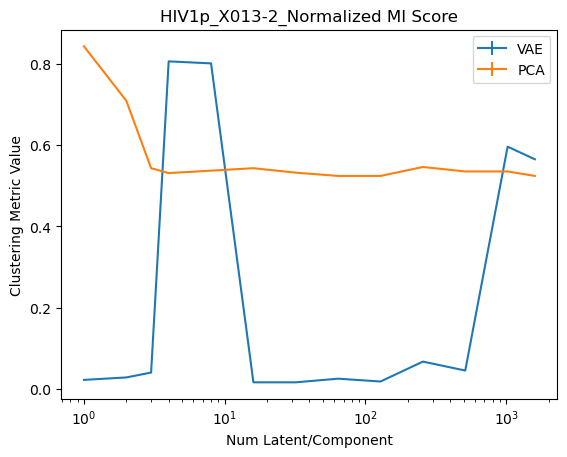

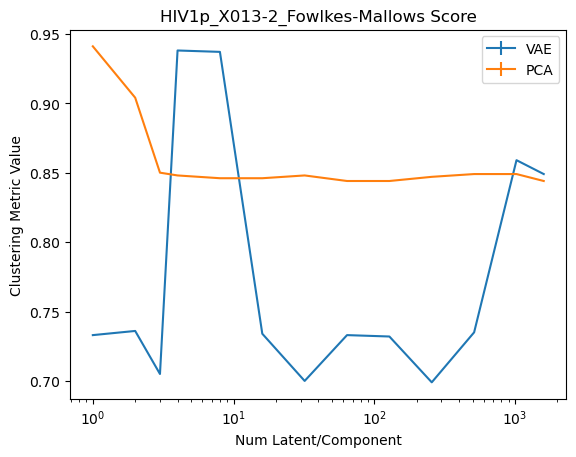

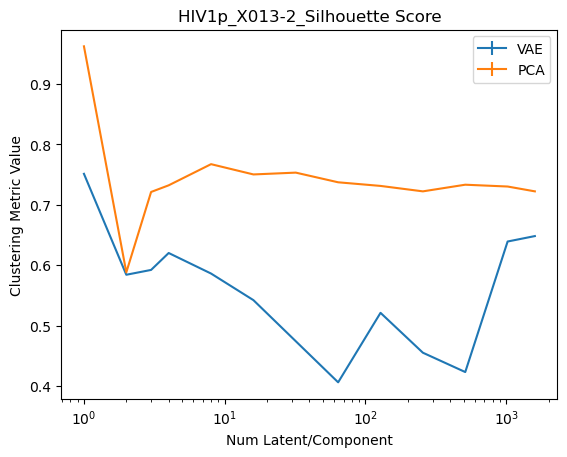

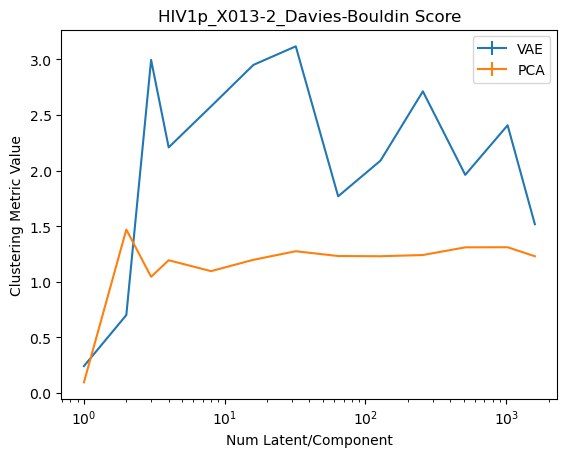

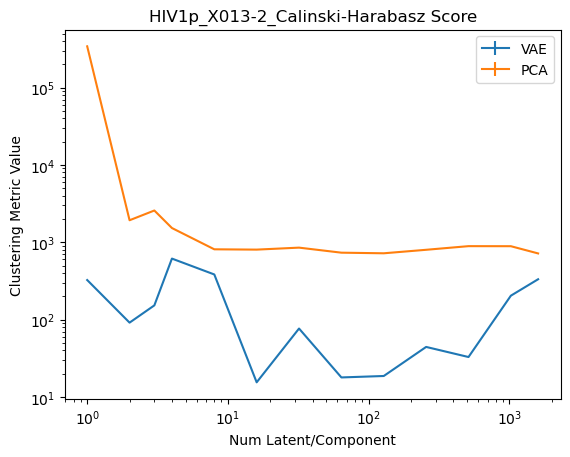

In [5]:
base_model = 'X013-2'
for prefix in ['OX_', 'DA_', 'CR_', 'BR_', 'HIV1p_']:
    
    model_name2load = prefix+base_model
    
    json_fns = [fi for fi in json_files if model_name2load in fi]
    latents = [int(fns.split('_')[-2]) for fns in json_fns]
    
    rand = []
    mi = []
    fomal = []
    sils = []
    davbol = []
    calhar = []
    
    for fn, lat in zip(json_fns, latents):
        kmeans, aggl, hdbs = parse_clustering_log(fn)
        rand.append([kmeans[0], aggl[0], hdbs[0]])
        mi.append([kmeans[1], aggl[1], hdbs[1]])
        fomal.append([kmeans[2], aggl[2], hdbs[2]])
        sils.append([kmeans[3], aggl[3], hdbs[3]])
        davbol.append([kmeans[4], aggl[4], hdbs[4]])
        calhar.append([kmeans[5], aggl[5], hdbs[5]])
    
    
    for i, metric in enumerate([rand, mi, fomal, sils, davbol, calhar]):
        title=title_key[i]
        plot_metric(metric, latents, method=2, title=model_name2load +'_'+title_key[i], show=True)

### Analyze smthn

In [1]:
import os, sys, glob, json
import numpy as np

In [2]:
json_list_file = 'best_model_list_X013-2.txt'

with open(json_list_file, 'r') as f:
    json_files_1to4 = [line[:-1] for line in f.readlines() if line.endswith('\n') and True in [elem in line for elem in ['0001', '0002', '0003', '0004']]]

In [3]:
def get_model_data(model_name):
    data = {}
    for lat in ['0001', '0002', '0003', '0004']:
        vae_numpy_fn = glob.glob(f'/ocean/projects/cis250004p/josephdb/Deep-MMS/comp_stor/{model_name}/*{lat}*/*/VAE_latents.npy')[0]
        pca_numpy_fn = glob.glob(f'/ocean/projects/cis250004p/josephdb/Deep-MMS/comp_stor/{model_name}/*{lat}*/*/PCA_latents.npy')[0]
        vae_dist_mat_fn = glob.glob(f'/ocean/projects/cis250004p/josephdb/Deep-MMS/comp_stor/{model_name}/*{lat}*/*/VAE_latents_L2_distance_matrix.npy')[0]
        pca_dist_mat_fn = glob.glob(f'/ocean/projects/cis250004p/josephdb/Deep-MMS/comp_stor/{model_name}/*{lat}*/*/PCA_latents_L2_distance_matrix.npy')[0]
        test_l2 = glob.glob(f'/ocean/projects/cis250004p/josephdb/Deep-MMS/comp_stor/{model_name}/*{lat}*/*/L2_test_distance_matrix.npy')[0]
        test_rmsd = glob.glob(f'/ocean/projects/cis250004p/josephdb/Deep-MMS/comp_stor/{model_name}/*{lat}*/*/RMSD_test_distance_matrix.npy')[0]
        data[lat] = {'VAE_vecs': np.load(vae_numpy_fn),
                     'PCA_vecs': np.load(pca_numpy_fn),
                     'VAE_L2': np.load(vae_dist_mat_fn),
                     'PCA_L2': np.load(pca_dist_mat_fn),
                     'Test_L2': np.load(test_l2),
                     'Test_RMSD': np.load(test_rmsd)}
    return data

OX_X013-2
0001
lat_set='VAE_L2'	ref_set='Test_L2'	PearsonRResult(statistic=0.16669291464391556, pvalue=6.345665492110803e-14)
lat_set='VAE_L2'	ref_set='Test_L2'	SignificanceResult(statistic=0.15270911138270565, pvalue=6.71119136272616e-12)
lat_set='VAE_L2'	ref_set='Test_L2'	SignificanceResult(statistic=0.10225027832852653, pvalue=7.319234426919205e-12)
lat_set='PCA_L2'	ref_set='Test_L2'	PearsonRResult(statistic=0.6830397447169613, pvalue=8.424298097873433e-275)
lat_set='PCA_L2'	ref_set='Test_L2'	SignificanceResult(statistic=0.6240773494855536, pvalue=3.039233432435908e-216)
lat_set='PCA_L2'	ref_set='Test_L2'	SignificanceResult(statistic=0.46435880602964147, pvalue=1.5047245351426278e-212)


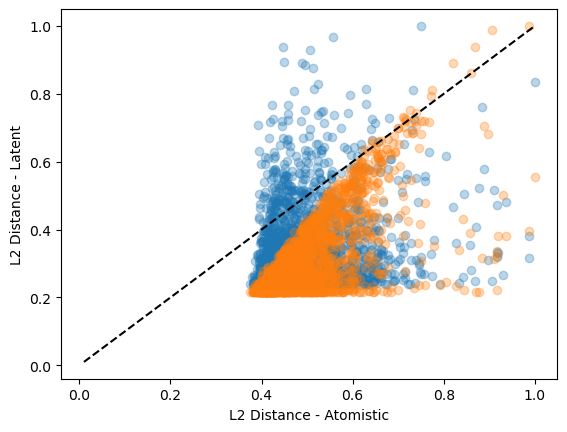

0002
lat_set='VAE_L2'	ref_set='Test_L2'	PearsonRResult(statistic=0.505855176414709, pvalue=2.0547150880198762e-130)
lat_set='VAE_L2'	ref_set='Test_L2'	SignificanceResult(statistic=0.3636130974032743, pvalue=1.4572000111486283e-63)
lat_set='VAE_L2'	ref_set='Test_L2'	SignificanceResult(statistic=0.25312756378189094, pvalue=1.4791782828806047e-64)
lat_set='PCA_L2'	ref_set='Test_L2'	PearsonRResult(statistic=0.8757314212893285, pvalue=0.0)
lat_set='PCA_L2'	ref_set='Test_L2'	SignificanceResult(statistic=0.9101746510436627, pvalue=0.0)
lat_set='PCA_L2'	ref_set='Test_L2'	SignificanceResult(statistic=0.7717318659329665, pvalue=0.0)


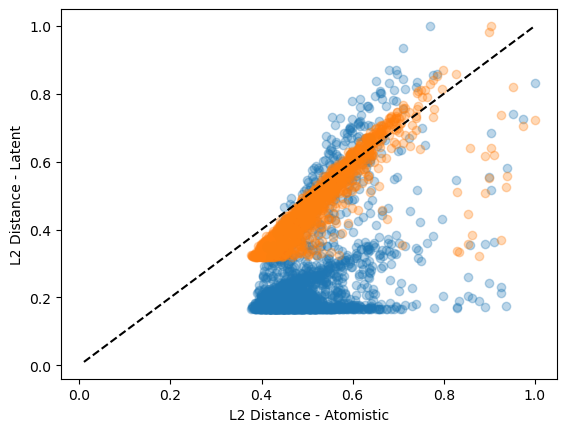

0003
lat_set='VAE_L2'	ref_set='Test_L2'	PearsonRResult(statistic=0.8524511380395187, pvalue=0.0)
lat_set='VAE_L2'	ref_set='Test_L2'	SignificanceResult(statistic=0.8953617288404322, pvalue=0.0)
lat_set='VAE_L2'	ref_set='Test_L2'	SignificanceResult(statistic=0.7339799899949975, pvalue=0.0)
lat_set='PCA_L2'	ref_set='Test_L2'	PearsonRResult(statistic=0.9358713951041879, pvalue=0.0)
lat_set='PCA_L2'	ref_set='Test_L2'	SignificanceResult(statistic=0.970810984202746, pvalue=0.0)
lat_set='PCA_L2'	ref_set='Test_L2'	SignificanceResult(statistic=0.8646783391695847, pvalue=0.0)


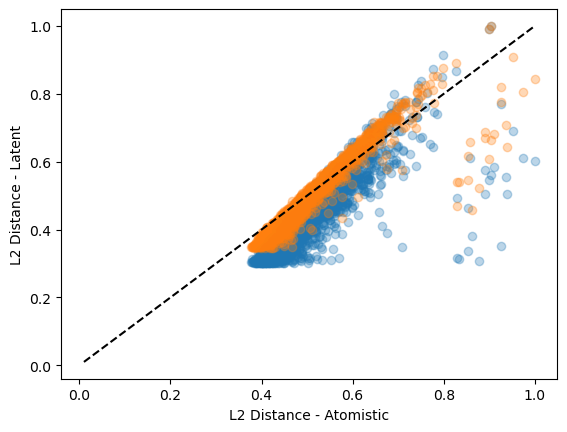

0004
lat_set='VAE_L2'	ref_set='Test_L2'	PearsonRResult(statistic=0.8538257642280795, pvalue=0.0)
lat_set='VAE_L2'	ref_set='Test_L2'	SignificanceResult(statistic=0.9174932143733037, pvalue=0.0)
lat_set='VAE_L2'	ref_set='Test_L2'	SignificanceResult(statistic=0.7458459229614807, pvalue=0.0)
lat_set='PCA_L2'	ref_set='Test_L2'	PearsonRResult(statistic=0.9888317472814225, pvalue=0.0)
lat_set='PCA_L2'	ref_set='Test_L2'	SignificanceResult(statistic=0.9769346937336734, pvalue=0.0)
lat_set='PCA_L2'	ref_set='Test_L2'	SignificanceResult(statistic=0.8814957478739369, pvalue=0.0)


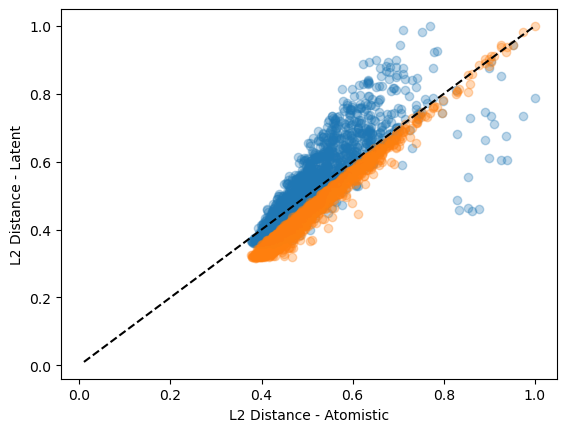

DA_X013-2
0001
lat_set='VAE_L2'	ref_set='Test_L2'	PearsonRResult(statistic=0.024383713090089763, pvalue=0.27573380160180316)
lat_set='VAE_L2'	ref_set='Test_L2'	SignificanceResult(statistic=-0.2270395812598953, pvalue=8.519039357165443e-25)
lat_set='VAE_L2'	ref_set='Test_L2'	SignificanceResult(statistic=-0.11928764382191095, pvalue=1.2950836837134362e-15)
lat_set='PCA_L2'	ref_set='Test_L2'	PearsonRResult(statistic=0.09234882786559326, pvalue=3.530670683984951e-05)
lat_set='PCA_L2'	ref_set='Test_L2'	SignificanceResult(statistic=0.038244203061050766, pvalue=0.08728639862450197)
lat_set='PCA_L2'	ref_set='Test_L2'	SignificanceResult(statistic=0.04969884942471236, pvalue=0.0008653914839949535)


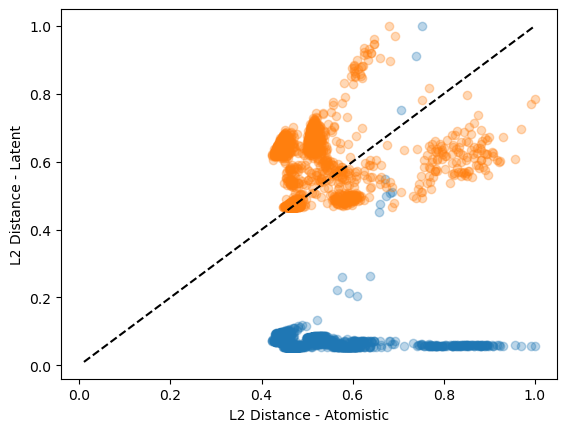

0002
lat_set='VAE_L2'	ref_set='Test_L2'	PearsonRResult(statistic=0.6144531948209805, pvalue=5.90482188656453e-208)
lat_set='VAE_L2'	ref_set='Test_L2'	SignificanceResult(statistic=0.14888096972024242, pvalue=2.211661631035376e-11)
lat_set='VAE_L2'	ref_set='Test_L2'	SignificanceResult(statistic=0.1180840420210105, pvalue=2.48462653123597e-15)
lat_set='PCA_L2'	ref_set='Test_L2'	PearsonRResult(statistic=0.816868476578813, pvalue=0.0)
lat_set='PCA_L2'	ref_set='Test_L2'	SignificanceResult(statistic=0.43724998181249547, pvalue=3.547529762546607e-94)
lat_set='PCA_L2'	ref_set='Test_L2'	SignificanceResult(statistic=0.34198199099549775, pvalue=2.882845914716421e-116)


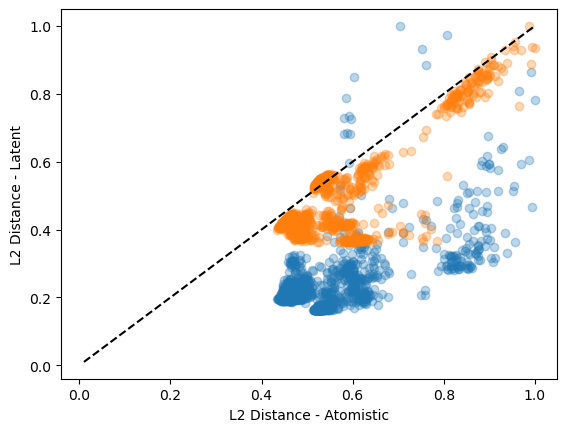

0003
lat_set='VAE_L2'	ref_set='Test_L2'	PearsonRResult(statistic=0.7520383110110059, pvalue=0.0)
lat_set='VAE_L2'	ref_set='Test_L2'	SignificanceResult(statistic=0.8474863413715853, pvalue=0.0)
lat_set='VAE_L2'	ref_set='Test_L2'	SignificanceResult(statistic=0.689240620310155, pvalue=0.0)
lat_set='PCA_L2'	ref_set='Test_L2'	PearsonRResult(statistic=0.911063079086111, pvalue=0.0)
lat_set='PCA_L2'	ref_set='Test_L2'	SignificanceResult(statistic=0.753021255755314, pvalue=0.0)
lat_set='PCA_L2'	ref_set='Test_L2'	SignificanceResult(statistic=0.6440910455227613, pvalue=0.0)


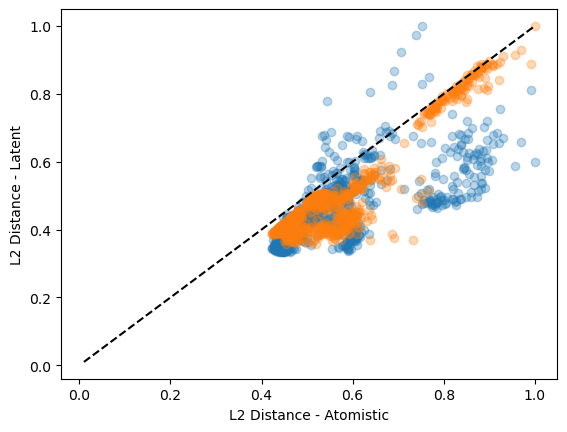

0004
lat_set='VAE_L2'	ref_set='Test_L2'	PearsonRResult(statistic=0.7469287018284269, pvalue=0.0)
lat_set='VAE_L2'	ref_set='Test_L2'	SignificanceResult(statistic=0.8400805035201258, pvalue=0.0)
lat_set='VAE_L2'	ref_set='Test_L2'	SignificanceResult(statistic=0.6510675337668834, pvalue=0.0)
lat_set='PCA_L2'	ref_set='Test_L2'	PearsonRResult(statistic=0.9492744930046569, pvalue=0.0)
lat_set='PCA_L2'	ref_set='Test_L2'	SignificanceResult(statistic=0.8480386415096605, pvalue=0.0)
lat_set='PCA_L2'	ref_set='Test_L2'	SignificanceResult(statistic=0.7419159579789895, pvalue=0.0)


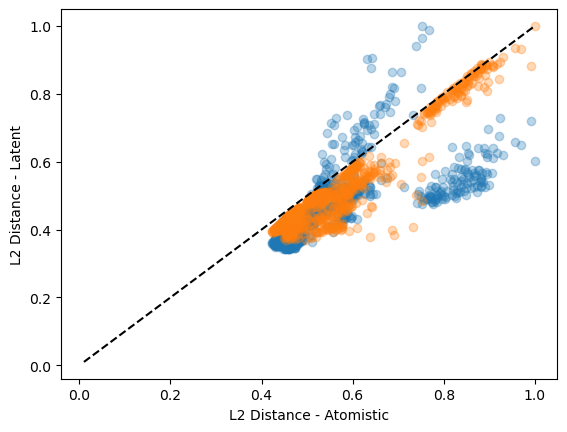

CR_X013-2
0001
lat_set='VAE_L2'	ref_set='Test_L2'	PearsonRResult(statistic=0.6198041331503554, pvalue=1.3785111617360674e-212)
lat_set='VAE_L2'	ref_set='Test_L2'	SignificanceResult(statistic=-0.039239909309977325, pvalue=0.07935502608461534)
lat_set='VAE_L2'	ref_set='Test_L2'	SignificanceResult(statistic=-0.028189094547273634, pvalue=0.058847800494563944)
lat_set='PCA_L2'	ref_set='Test_L2'	PearsonRResult(statistic=0.7430712291529804, pvalue=0.0)
lat_set='PCA_L2'	ref_set='Test_L2'	SignificanceResult(statistic=0.2685313136328284, pvalue=2.2349956307412865e-34)
lat_set='PCA_L2'	ref_set='Test_L2'	SignificanceResult(statistic=0.19246123061530765, pvalue=4.5359076565105034e-38)


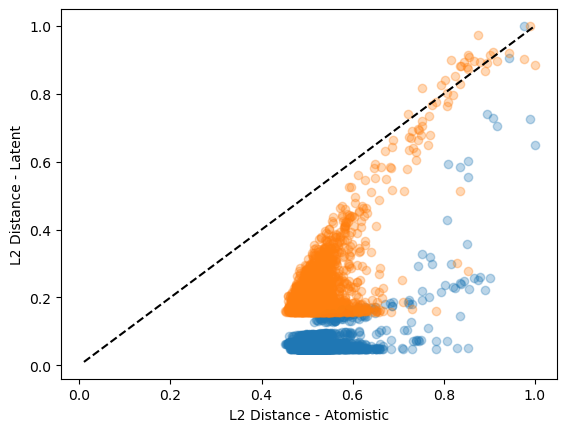

0002
lat_set='VAE_L2'	ref_set='Test_L2'	PearsonRResult(statistic=0.7717018770446933, pvalue=0.0)
lat_set='VAE_L2'	ref_set='Test_L2'	SignificanceResult(statistic=0.5589824582456145, pvalue=9.194092431092656e-165)
lat_set='VAE_L2'	ref_set='Test_L2'	SignificanceResult(statistic=0.4013586793396698, pvalue=2.1715436820602632e-159)
lat_set='PCA_L2'	ref_set='Test_L2'	PearsonRResult(statistic=0.8149476595963292, pvalue=0.0)
lat_set='PCA_L2'	ref_set='Test_L2'	SignificanceResult(statistic=0.4800240765060191, pvalue=8.617196913399883e-116)
lat_set='PCA_L2'	ref_set='Test_L2'	SignificanceResult(statistic=0.3484212106053026, pvalue=1.3038040156372837e-120)


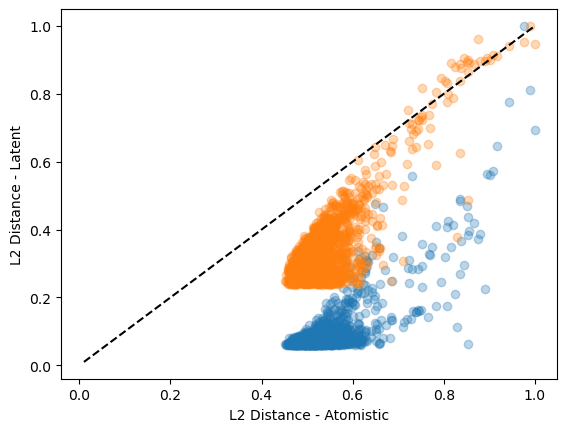

0003
lat_set='VAE_L2'	ref_set='Test_L2'	PearsonRResult(statistic=0.7679869029175169, pvalue=0.0)
lat_set='VAE_L2'	ref_set='Test_L2'	SignificanceResult(statistic=0.4810735817683954, pvalue=2.3194884856343568e-116)
lat_set='VAE_L2'	ref_set='Test_L2'	SignificanceResult(statistic=0.33802701350675335, pvalue=1.2253541368813824e-113)
lat_set='PCA_L2'	ref_set='Test_L2'	PearsonRResult(statistic=0.8553438580008381, pvalue=0.0)
lat_set='PCA_L2'	ref_set='Test_L2'	SignificanceResult(statistic=0.6891433347858337, pvalue=8.3080580715333e-282)
lat_set='PCA_L2'	ref_set='Test_L2'	SignificanceResult(statistic=0.5136618309154577, pvalue=9.827391371997399e-260)


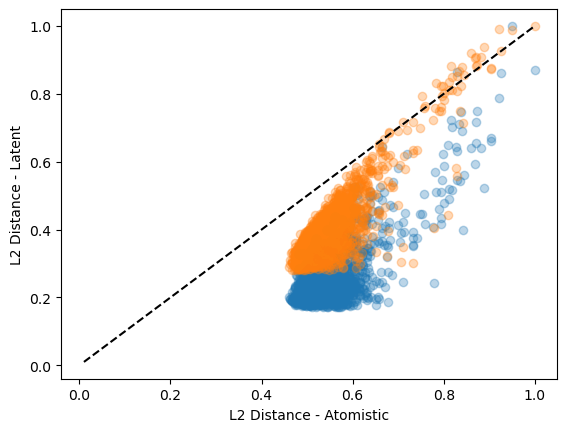

0004
lat_set='VAE_L2'	ref_set='Test_L2'	PearsonRResult(statistic=0.8386607960446146, pvalue=0.0)
lat_set='VAE_L2'	ref_set='Test_L2'	SignificanceResult(statistic=0.753817299954325, pvalue=0.0)
lat_set='VAE_L2'	ref_set='Test_L2'	SignificanceResult(statistic=0.5678839419709855, pvalue=0.0)
lat_set='PCA_L2'	ref_set='Test_L2'	PearsonRResult(statistic=0.9051560453260629, pvalue=0.0)
lat_set='PCA_L2'	ref_set='Test_L2'	SignificanceResult(statistic=0.7934720808680201, pvalue=0.0)
lat_set='PCA_L2'	ref_set='Test_L2'	SignificanceResult(statistic=0.6104872436218108, pvalue=0.0)


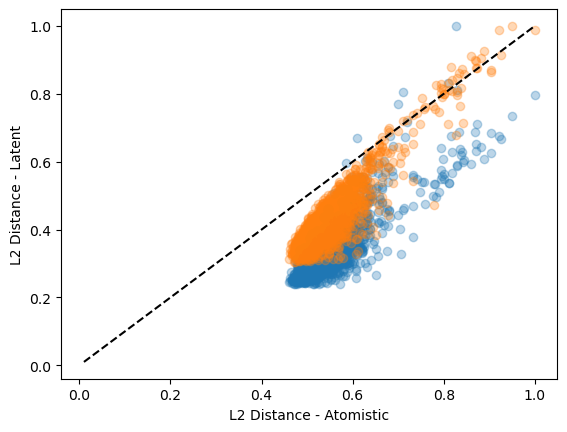

BR_X013-2
0001
lat_set='VAE_L2'	ref_set='Test_L2'	PearsonRResult(statistic=0.937934392417694, pvalue=0.0)
lat_set='VAE_L2'	ref_set='Test_L2'	SignificanceResult(statistic=0.6039465279465279, pvalue=1.9472694321104777e-100)
lat_set='VAE_L2'	ref_set='Test_L2'	SignificanceResult(statistic=0.4538538538538539, pvalue=1.907744157852084e-102)
lat_set='PCA_L2'	ref_set='Test_L2'	PearsonRResult(statistic=0.9558496201199557, pvalue=0.0)
lat_set='PCA_L2'	ref_set='Test_L2'	SignificanceResult(statistic=0.7163011523011523, pvalue=3.844510572332176e-158)
lat_set='PCA_L2'	ref_set='Test_L2'	SignificanceResult(statistic=0.5603843843843844, pvalue=3.8341307058963e-155)


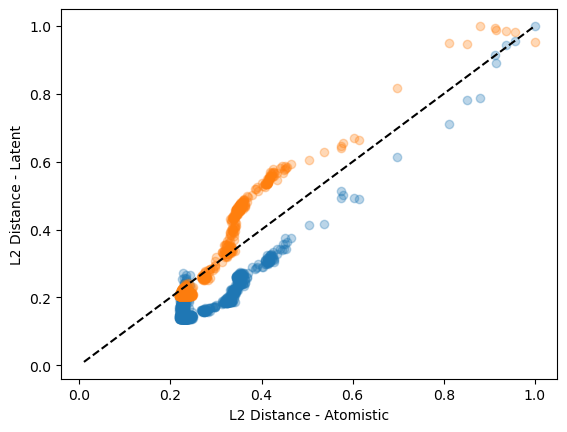

0002
lat_set='VAE_L2'	ref_set='Test_L2'	PearsonRResult(statistic=0.961114159619087, pvalue=0.0)
lat_set='VAE_L2'	ref_set='Test_L2'	SignificanceResult(statistic=0.7264163224163225, pvalue=9.64528576170735e-165)
lat_set='VAE_L2'	ref_set='Test_L2'	SignificanceResult(statistic=0.5623463463463463, pvalue=3.2335966251256444e-156)
lat_set='PCA_L2'	ref_set='Test_L2'	PearsonRResult(statistic=0.9852508863656563, pvalue=0.0)
lat_set='PCA_L2'	ref_set='Test_L2'	SignificanceResult(statistic=0.7643529203529204, pvalue=2.1065769515169103e-192)
lat_set='PCA_L2'	ref_set='Test_L2'	SignificanceResult(statistic=0.6078158158158158, pvalue=3.723818910593017e-182)


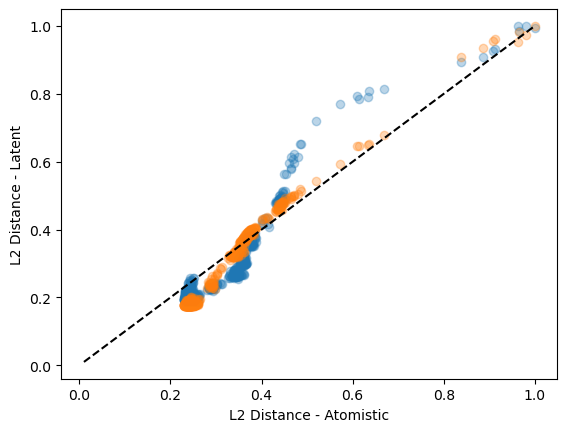

0003
lat_set='VAE_L2'	ref_set='Test_L2'	PearsonRResult(statistic=0.9442223647554484, pvalue=0.0)
lat_set='VAE_L2'	ref_set='Test_L2'	SignificanceResult(statistic=0.6214379974379975, pvalue=6.899641851008238e-108)
lat_set='VAE_L2'	ref_set='Test_L2'	SignificanceResult(statistic=0.4713233233233234, pvalue=2.4838775415270847e-110)
lat_set='PCA_L2'	ref_set='Test_L2'	PearsonRResult(statistic=0.9933804391595276, pvalue=0.0)
lat_set='PCA_L2'	ref_set='Test_L2'	SignificanceResult(statistic=0.8559475239475239, pvalue=3.8528684348114174e-288)
lat_set='PCA_L2'	ref_set='Test_L2'	SignificanceResult(statistic=0.7058418418418418, pvalue=6.455676509420347e-245)


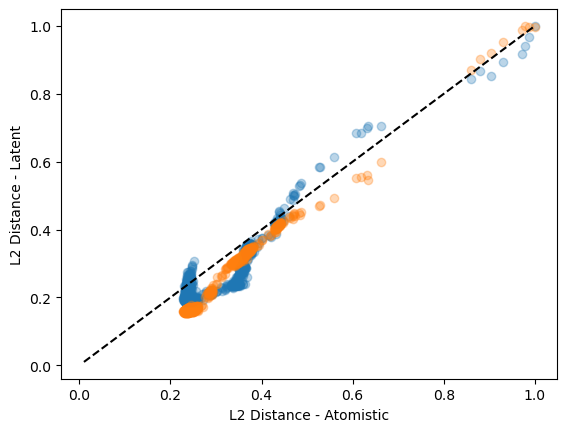

0004
lat_set='VAE_L2'	ref_set='Test_L2'	PearsonRResult(statistic=0.9594778240330455, pvalue=0.0)
lat_set='VAE_L2'	ref_set='Test_L2'	SignificanceResult(statistic=0.7751711284262626, pvalue=2.868411322938232e-201)
lat_set='VAE_L2'	ref_set='Test_L2'	SignificanceResult(statistic=0.6120076797368426, pvalue=1.2040166334015151e-184)
lat_set='PCA_L2'	ref_set='Test_L2'	PearsonRResult(statistic=0.9944892586310319, pvalue=0.0)
lat_set='PCA_L2'	ref_set='Test_L2'	SignificanceResult(statistic=0.9302826782826784, pvalue=0.0)
lat_set='PCA_L2'	ref_set='Test_L2'	SignificanceResult(statistic=0.8041321321321322, pvalue=0.0)


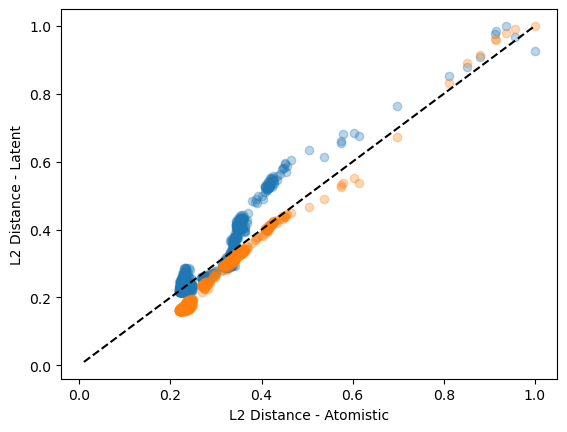

HIV1p_X013-2
0001
lat_set='VAE_L2'	ref_set='Test_L2'	PearsonRResult(statistic=0.7564005456650875, pvalue=0.0)
lat_set='VAE_L2'	ref_set='Test_L2'	SignificanceResult(statistic=0.7487373038074319, pvalue=0.0)
lat_set='VAE_L2'	ref_set='Test_L2'	SignificanceResult(statistic=0.538578827993094, pvalue=2.4965075226838556e-285)
lat_set='PCA_L2'	ref_set='Test_L2'	PearsonRResult(statistic=0.9303934671674794, pvalue=0.0)
lat_set='PCA_L2'	ref_set='Test_L2'	SignificanceResult(statistic=0.8942124239737652, pvalue=0.0)
lat_set='PCA_L2'	ref_set='Test_L2'	SignificanceResult(statistic=0.7070228649439929, pvalue=0.0)


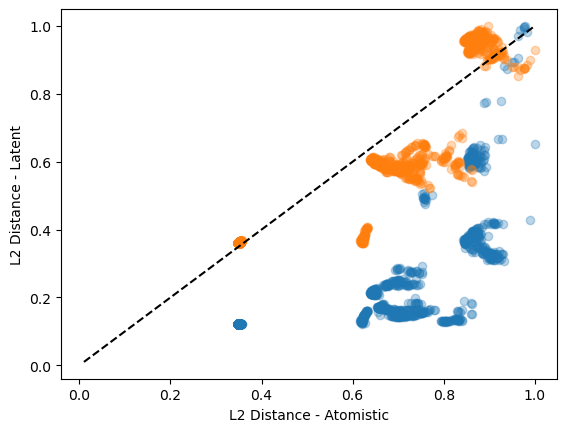

0002
lat_set='VAE_L2'	ref_set='Test_L2'	PearsonRResult(statistic=0.6711818126654658, pvalue=4.6135505425647677e-262)
lat_set='VAE_L2'	ref_set='Test_L2'	SignificanceResult(statistic=0.7970978532744633, pvalue=0.0)
lat_set='VAE_L2'	ref_set='Test_L2'	SignificanceResult(statistic=0.5586233116558279, pvalue=8.470172414148111e-307)
lat_set='PCA_L2'	ref_set='Test_L2'	PearsonRResult(statistic=0.9626354135476625, pvalue=0.0)
lat_set='PCA_L2'	ref_set='Test_L2'	SignificanceResult(statistic=0.9020172230043056, pvalue=0.0)
lat_set='PCA_L2'	ref_set='Test_L2'	SignificanceResult(statistic=0.7344952476238118, pvalue=0.0)


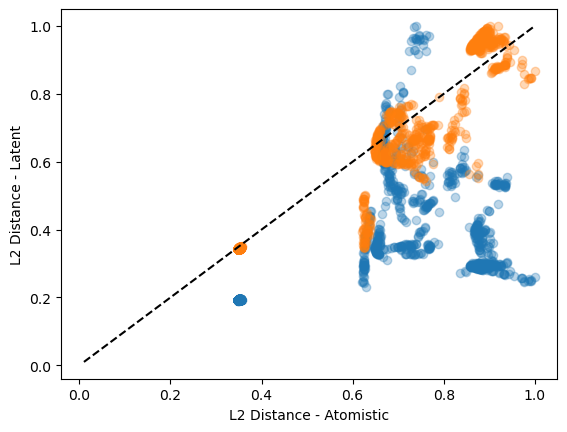

0003
lat_set='VAE_L2'	ref_set='Test_L2'	PearsonRResult(statistic=0.8529597869712913, pvalue=0.0)
lat_set='VAE_L2'	ref_set='Test_L2'	SignificanceResult(statistic=0.8360990420247605, pvalue=0.0)
lat_set='VAE_L2'	ref_set='Test_L2'	SignificanceResult(statistic=0.6246503251625812, pvalue=0.0)
lat_set='PCA_L2'	ref_set='Test_L2'	PearsonRResult(statistic=0.9787988285037688, pvalue=0.0)
lat_set='PCA_L2'	ref_set='Test_L2'	SignificanceResult(statistic=0.910402088600522, pvalue=0.0)
lat_set='PCA_L2'	ref_set='Test_L2'	SignificanceResult(statistic=0.7558129064532265, pvalue=0.0)


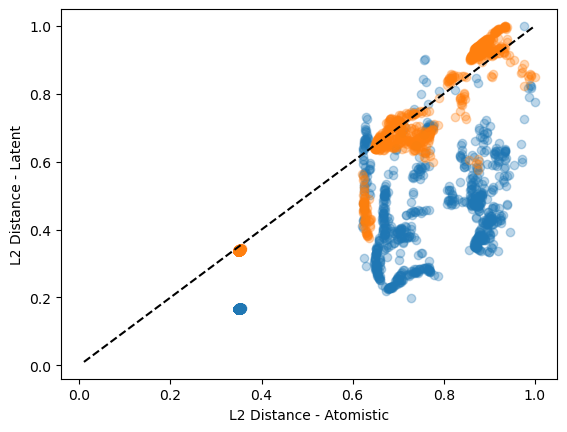

0004
lat_set='VAE_L2'	ref_set='Test_L2'	PearsonRResult(statistic=0.9291767419386401, pvalue=0.0)
lat_set='VAE_L2'	ref_set='Test_L2'	SignificanceResult(statistic=0.7469921977480495, pvalue=0.0)
lat_set='VAE_L2'	ref_set='Test_L2'	SignificanceResult(statistic=0.5298699349674837, pvalue=3.023070043895509e-276)
lat_set='PCA_L2'	ref_set='Test_L2'	PearsonRResult(statistic=0.9910336876774755, pvalue=0.0)
lat_set='PCA_L2'	ref_set='Test_L2'	SignificanceResult(statistic=0.9178705169676291, pvalue=0.0)
lat_set='PCA_L2'	ref_set='Test_L2'	SignificanceResult(statistic=0.7726843421710855, pvalue=0.0)


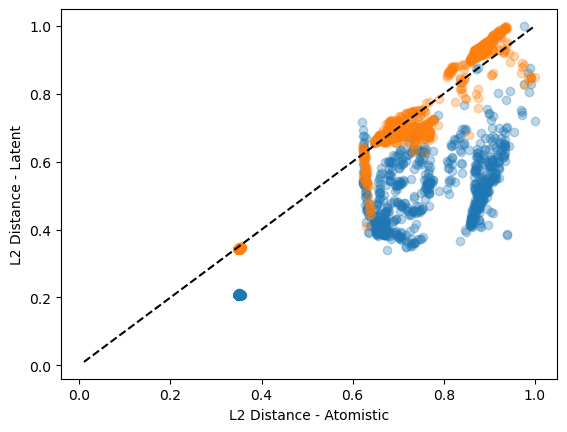

In [9]:
import numpy as np
import matplotlib.pyplot as plt
import scipy
pearsonr = scipy.stats.pearsonr
spearmanrho = scipy.stats.spearmanr
kendalltau = scipy.stats.kendalltau

for model_fn in ['OX_X013-2', 'DA_X013-2', 'CR_X013-2', 'BR_X013-2', 'HIV1p_X013-2']:
    data = get_model_data(model_fn)
    print(model_fn)
    for lat, subdat in data.items():
        print(lat)
        for lat_set in ['VAE_L2', 'PCA_L2']:
            ref_set = 'Test_L2'
            for metric in [pearsonr, spearmanrho, kendalltau]:
                print(f"{lat_set=}\t{ref_set=}\t{metric(data[lat][lat_set].mean(axis=0), data[lat][ref_set].mean(axis=0))}")

        plt.clf()
        xs = data[lat]['Test_L2'].mean(axis=1)
        ys1 = data[lat]['VAE_L2'].mean(axis=1)
        ys2 = data[lat]['PCA_L2'].mean(axis=1)
        xs /= xs.max()
        ys1 /= ys1.max()
        ys2 /= ys2.max()
        plt.scatter(xs, ys1, alpha=0.3)
        plt.scatter(xs, ys2, alpha=0.3)
        plt.xlabel('L2 Distance - Atomistic')
        plt.ylabel('L2 Distance - Latent')
        plt.plot([0.01, 1],[0.01, 1], linestyle='dashed', color='k')
        plt.show()

In [ ]:
data = get_model_data('DA_X013-2')

In [12]:
data['0001']['VAE_L2'].shape

(1999, 1999)

0001
lat_set='VAE_L2'	ref_set='Test_L2'	PearsonRResult(statistic=0.16669291464391556, pvalue=6.345665492110803e-14)
lat_set='VAE_L2'	ref_set='Test_L2'	SignificanceResult(statistic=0.15270911138270565, pvalue=6.71119136272616e-12)
lat_set='VAE_L2'	ref_set='Test_L2'	SignificanceResult(statistic=0.10225027832852653, pvalue=7.319234426919205e-12)
lat_set='PCA_L2'	ref_set='Test_L2'	PearsonRResult(statistic=0.6830397351234255, pvalue=8.424504869369032e-275)
lat_set='PCA_L2'	ref_set='Test_L2'	SignificanceResult(statistic=0.6240773494855536, pvalue=3.039233432435908e-216)
lat_set='PCA_L2'	ref_set='Test_L2'	SignificanceResult(statistic=0.46435880602964147, pvalue=1.5047245351426278e-212)
0002
lat_set='VAE_L2'	ref_set='Test_L2'	PearsonRResult(statistic=0.505855176414709, pvalue=2.0547150880198762e-130)
lat_set='VAE_L2'	ref_set='Test_L2'	SignificanceResult(statistic=0.3636130974032743, pvalue=1.4572000111486283e-63)
lat_set='VAE_L2'	ref_set='Test_L2'	SignificanceResult(statistic=0.253127563781890

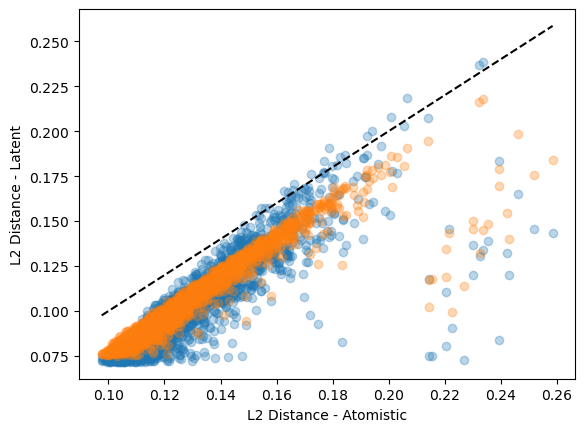

In [16]:
lat = '0003'

xs = data['0003']['Test_L2'].mean(axis=1)
ys1 = data['0003']['VAE_L2'].mean(axis=1)
ys2 = data['0003']['PCA_L2'].mean(axis=1)

plt.scatter(xs, ys1, alpha=0.3)
plt.scatter(xs, ys2, alpha=0.3)
plt.xlabel('L2 Distance - Atomistic')
plt.ylabel('L2 Distance - Latent')
plt.plot([xs.min(), xs.max()],[xs.min(), xs.max()], linestyle='dashed', color='k')
#plt.xlim((1.5, 3.5))
#plt.ylim((0.5, 3.5))

# slope, intercept = np.polyfit(xs, ys, 1)
# func = lambda x: slope*x + intercept
# domain = np.linspace(xs.min(), xs.max(), 100)
# raneg = func(domain)
# plt.scatter(domain, raneg, alpha=0.5, color='k')
# plt.xlim((domain.min() - 0.1*domain_size, domain.max() + 0.1*domain_size))
# plt.ylim((raneg.min() - 0.1*domain_size, raneg.max() + 0.1*domain_size))

In [1]:
# #Cluster the VAE and PCA data using (a method, say HDBScan)
# for latent, data_dict in data.items():
#     print(latent)
#     vae_data = data_dict['VAE']
#     vae_dist = euclidean_distance_matrix(vae_data)
#     pca_data = data_dict['PCA']
#     pca_dist = euclidean_distance_matrix(pca_data)
#     print(vae_data.shape, vae_dist.shape, pca_data.shape, pca_dist.shape)

### Analyze Perturbations in Two D

In [2]:
with open('best_model_list_X013-2.txt', 'r') as f:
    twoD_bestmodels = [elem for elem in f.read().split('\n') if elem and '_0002_' in elem]

In [3]:
import jax
from _02_write_viollin_data import HeavyAtom_Analyzer, atom_rmsd
def operate(heavy_atom_analyzer, data, rng_seed):
    key = jax.random.PRNGKey(rng_seed)
    main_key, dropout_key = jax.random.split(key, num=2)
    arg_dict = {'params': heavy_atom_analyzer.state.params}
    if heavy_atom_analyzer.is_batchnorm:
        arg_dict['batch_stats'] = heavy_atom_analyzer.state.batch_stats
    decoded, latent_means, latent_vars = heavy_atom_analyzer.state.apply_fn(arg_dict, data, main_key, train=False, rngs={'dropout': dropout_key})
    return decoded, latent_means, latent_vars

In [4]:
# for json_fn in twoD_bestmodels[:3]:
#     ha = HeavyAtom_Analyzer(json_fn)
#     _, latent_means, _ = operate(ha, ha.test_data, 4569)

In [5]:
import glob, os
import numpy as np
import matplotlib.pyplot as plt
latent_means_numpys = sorted(glob.glob('*_BestTestMeans.npy'))

In [6]:
latent_means_numpys

['BR_X013-2_0002_BestTestMeans.npy',
 'CR_X013-2_0002_BestTestMeans.npy',
 'DA_X013-2_0002_BestTestMeans.npy',
 'DA_stretch_X013-2_0002_BestTestMeans.npy',
 'HIV1p_X013-2_0002_BestTestMeans.npy',
 'OX_X013-2_0002_BestTestMeans.npy']

In [21]:
def write_numpy_as(topfn, numpy_arr, file_name, write_mode='dcd'):
    import mdtraj as md
    import numpy as np
    import os
    ref = md.load_pdb(topfn)
    ref = ref.atom_slice(ref.topology.select('not element H'))
    topology = ref.topology
    new = md.Trajectory(xyz=numpy_arr, topology=topology)
    if write_mode == 'pdb':
        new[0].save_pdb(file_name)
    elif write_mode == 'dcd':
        new.save_dcd(file_name)

In [6]:
def euclidean_distance_matrix(vectors, func=None):
    import jax.numpy as jnp
    """
    Calculate the euclidean distance matrix between the array of vectors, give as (n_samples, n_features) returns
    (n_samples, n_samples) distance matrix where the ith row is all particles compared to sample i
        func - optionally provide a function to use for the distance between two vectors - otherwise the Euclidean (L2) distance will be used.
    
    """
    import inspect
    distance = jnp.empty((vectors.shape[0], vectors.shape[0]))
    
    if inspect.isfunction(func):
        func = jax.vamp(func, in_axes=(None, 0))
    elif func is None:
        func = jax.vmap(lambda a, b: jnp.sqrt(jnp.sum((b-a)**2)), in_axes=(None, 0))

    for i in range(vectors.shape[0]):
        distance = distance.at[i, :].set(func(vectors[i], vectors))
    return distance

In [23]:
latent_means_numpys

['BR_X013-2_0002_BestTestMeans.npy',
 'CR_X013-2_0002_BestTestMeans.npy',
 'DA_X013-2_0002_BestTestMeans.npy',
 'DA_stretch_X013-2_0002_BestTestMeans.npy',
 'HIV1p_X013-2_0002_BestTestMeans.npy',
 'OX_X013-2_0002_BestTestMeans.npy']

In [24]:
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, AgglomerativeClustering, HDBSCAN
from sklearn.metrics import rand_score, normalized_mutual_info_score, fowlkes_mallows_score
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score

topology_map = {'BR_X013-2_0002_BestTestMeans.npy': 'Simulation/3mxf_implicit.pdb',
                'CR_X013-2_0002_BestTestMeans.npy': 'Simulation/1crn_H.pdb',
                'DA_X013-2_0002_BestTestMeans.npy': 'Simulation/ala_deca_peptide.pdb',
                'DA_stretch_X013-2_0002_BestTestMeans.npy': 'Simulation/ala_deca_peptide.pdb',
                'HIV1p_X013-2_0002_BestTestMeans.npy': 'Simulation/HIV1p_protein_only.pdb',
                'OX_X013-2_0002_BestTestMeans.npy': 'Simulation/oxycodone.pdb'}

figure_dir = './figures/TwoD/'
if not os.path.isdir(figure_dir):
    os.mkdir(figure_dir)

In [25]:
def color_labels(labels):
    num_labels = np.max(labels) + 1
    cmap = np.empty((labels.shape[0], 3))
    colors = lambda x: [1-x/num_labels, np.abs(0.5-x/num_labels), x/num_labels]
    for i, label in enumerate(labels):
        if label == -1:
            cmap[i, :] = [0.0, 0.0, 0.0]
        else:
            cmap[i, :] = colors(label)
    return cmap 

In [26]:
def cluster_medioid_indices(dist_mat, labels):
    unique_labels = np.unique(labels)
    medoid_indices = []
    for i in unique_labels:
        if i == -1:
            continue
        cluster_distances = dist_mat[:, np.where(labels==i)][np.where(labels==i), :]
        medoid_cluster_index = np.argmin(np.mean(cluster_distances, axis=1))
        medoid_index = np.where(labels==i)[0][medoid_cluster_index]
        medoid_indices.append(medoid_index)
    return np.array(medoid_indices)

(array([-1,  0,  1,  2,  3,  4,  5,  6,  7,  8,  9]), array([ 65,  44,  51, 102,  53,  37,  52, 490,  59,  23,  24]))
BR_X013-2_0002_BestTestMeans.npy
color #1.1 rgb(1.0, 0.5, 0.0);color #1.2 rgb(0.9, 0.4, 0.1);color #1.3 rgb(0.8, 0.3, 0.2);color #1.4 rgb(0.7, 0.2, 0.3);color #1.5 rgb(0.6, 0.09999999999999998, 0.4);color #1.6 rgb(0.5, 0.0, 0.5);color #1.7 rgb(0.4, 0.09999999999999998, 0.6);color #1.8 rgb(0.30000000000000004, 0.19999999999999996, 0.7);color #1.9 rgb(0.19999999999999996, 0.30000000000000004, 0.8);color #1.10 rgb(0.09999999999999998, 0.4, 0.9)


<Figure size 640x480 with 0 Axes>

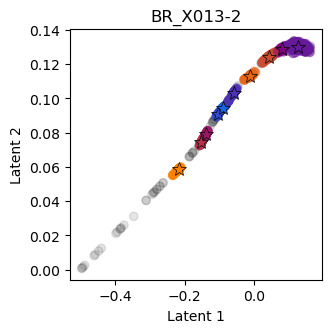

(array([-1,  0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10]), array([680,  30, 172,  30, 191,  27, 308,  20,  78,  75, 363,  26]))
CR_X013-2_0002_BestTestMeans.npy
color #1.1 rgb(1.0, 0.5, 0.0);color #1.2 rgb(0.9090909090909091, 0.40909090909090906, 0.09090909090909091);color #1.3 rgb(0.8181818181818181, 0.3181818181818182, 0.18181818181818182);color #1.4 rgb(0.7272727272727273, 0.2272727272727273, 0.2727272727272727);color #1.5 rgb(0.6363636363636364, 0.13636363636363635, 0.36363636363636365);color #1.6 rgb(0.5454545454545454, 0.04545454545454547, 0.45454545454545453);color #1.7 rgb(0.4545454545454546, 0.045454545454545414, 0.5454545454545454);color #1.8 rgb(0.36363636363636365, 0.13636363636363635, 0.6363636363636364);color #1.9 rgb(0.2727272727272727, 0.2272727272727273, 0.7272727272727273);color #1.10 rgb(0.18181818181818177, 0.31818181818181823, 0.8181818181818182);color #1.11 rgb(0.09090909090909094, 0.40909090909090906, 0.9090909090909091)


<Figure size 640x480 with 0 Axes>

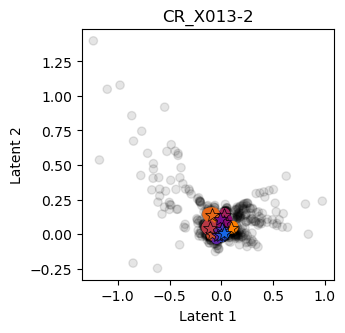

(array([-1,  0,  1,  2,  3,  4,  5,  6]), array([260,  48, 616, 461,  92,  26, 433,  64]))
DA_X013-2_0002_BestTestMeans.npy
color #1.1 rgb(1.0, 0.5, 0.0);color #1.2 rgb(0.8571428571428572, 0.35714285714285715, 0.14285714285714285);color #1.3 rgb(0.7142857142857143, 0.2142857142857143, 0.2857142857142857);color #1.4 rgb(0.5714285714285714, 0.07142857142857145, 0.42857142857142855);color #1.5 rgb(0.4285714285714286, 0.0714285714285714, 0.5714285714285714);color #1.6 rgb(0.2857142857142857, 0.2142857142857143, 0.7142857142857143);color #1.7 rgb(0.1428571428571429, 0.3571428571428571, 0.8571428571428571)


<Figure size 640x480 with 0 Axes>

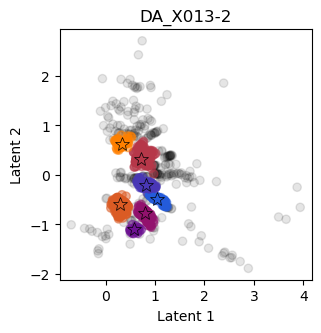

(array([-1,  0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14]), array([6010,  989,  535, 2031, 1925,  447,  364, 1691,  978,  474,  826,
        238, 1435, 1843,  864, 1349]))
DA_stretch_X013-2_0002_BestTestMeans.npy
color #1.1 rgb(1.0, 0.5, 0.0);color #1.2 rgb(0.9333333333333333, 0.43333333333333335, 0.06666666666666667);color #1.3 rgb(0.8666666666666667, 0.3666666666666667, 0.13333333333333333);color #1.4 rgb(0.8, 0.3, 0.2);color #1.5 rgb(0.7333333333333334, 0.23333333333333334, 0.26666666666666666);color #1.6 rgb(0.6666666666666667, 0.16666666666666669, 0.3333333333333333);color #1.7 rgb(0.6, 0.09999999999999998, 0.4);color #1.8 rgb(0.5333333333333333, 0.033333333333333326, 0.4666666666666667);color #1.9 rgb(0.4666666666666667, 0.033333333333333326, 0.5333333333333333);color #1.10 rgb(0.4, 0.09999999999999998, 0.6);color #1.11 rgb(0.33333333333333337, 0.16666666666666663, 0.6666666666666666);color #1.12 rgb(0.2666666666666667, 0.23333333333333328, 0.7333333333333333);color

<Figure size 640x480 with 0 Axes>

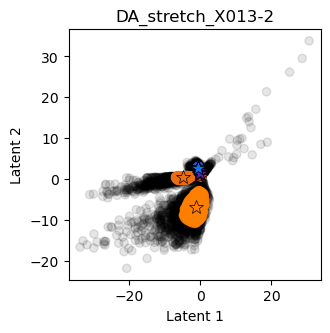

(array([-1,  0,  1,  2,  3,  4,  5,  6,  7,  8,  9]), array([ 187,   29,   61, 1231,   45,   95,   30,   64,   64,  162,   32]))
HIV1p_X013-2_0002_BestTestMeans.npy
color #1.1 rgb(1.0, 0.5, 0.0);color #1.2 rgb(0.9, 0.4, 0.1);color #1.3 rgb(0.8, 0.3, 0.2);color #1.4 rgb(0.7, 0.2, 0.3);color #1.5 rgb(0.6, 0.09999999999999998, 0.4);color #1.6 rgb(0.5, 0.0, 0.5);color #1.7 rgb(0.4, 0.09999999999999998, 0.6);color #1.8 rgb(0.30000000000000004, 0.19999999999999996, 0.7);color #1.9 rgb(0.19999999999999996, 0.30000000000000004, 0.8);color #1.10 rgb(0.09999999999999998, 0.4, 0.9)


<Figure size 640x480 with 0 Axes>

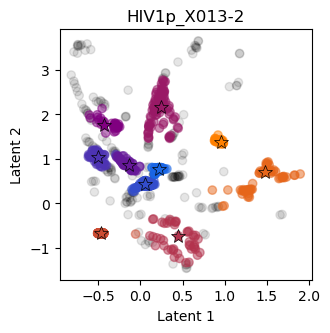

(array([-1,  0,  1,  2,  3,  4,  5,  6,  7,  8]), array([ 290,   70,   30,   68,   27,   21,   55,   36, 1378,   25]))
OX_X013-2_0002_BestTestMeans.npy
color #1.1 rgb(1.0, 0.5, 0.0);color #1.2 rgb(0.8888888888888888, 0.3888888888888889, 0.1111111111111111);color #1.3 rgb(0.7777777777777778, 0.2777777777777778, 0.2222222222222222);color #1.4 rgb(0.6666666666666667, 0.16666666666666669, 0.3333333333333333);color #1.5 rgb(0.5555555555555556, 0.05555555555555558, 0.4444444444444444);color #1.6 rgb(0.4444444444444444, 0.05555555555555558, 0.5555555555555556);color #1.7 rgb(0.33333333333333337, 0.16666666666666663, 0.6666666666666666);color #1.8 rgb(0.2222222222222222, 0.2777777777777778, 0.7777777777777778);color #1.9 rgb(0.11111111111111116, 0.38888888888888884, 0.8888888888888888)


<Figure size 640x480 with 0 Axes>

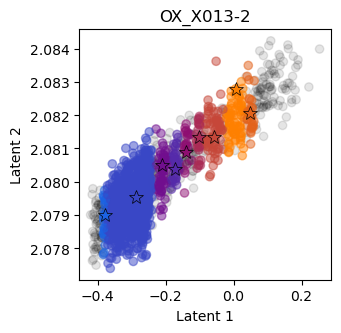

In [34]:
for npfn in latent_means_numpys:
    data = np.load(npfn)
    mean = data.mean(axis=0)
    #discover the closest actual datapoint to the mean
    centroid = data[np.argmin(np.sqrt(np.sum((data-mean)**2, axis=-1)))]
    #Cluster the data and report the centroids
    distance_matrix = np.load(npfn.replace('.npy', '_distmat.npy'))
    h = HDBSCAN(metric='precomputed', min_cluster_size=data.shape[0]//100)
    labels = h.fit_predict(distance_matrix)
    medoid_indices = cluster_medioid_indices(distance_matrix, labels)
    print(np.unique(labels, return_counts=True))
    
    decoded = np.load(npfn.replace('BestTestMeans','TestDecoded'))
    title = npfn.split('0002')[0][:-1]
    print(npfn)
    plt.clf()
    fig = plt.figure(figsize=(3.25, 3.25))
    
    colors = color_labels(labels)
    x_labeled = data[np.where(labels!=-1), 0]
    y_labeled = data[np.where(labels!=-1), 1]
    c_labeled = colors[np.where(labels!=-1)]
    plt.scatter(x=x_labeled, y=y_labeled, c=c_labeled, alpha=0.5)
    
    x_unlabeled = data[np.where(labels==-1), 0]
    y_unlabeled = data[np.where(labels==-1), 1]
    c_unlabeled = colors[np.where(labels==-1)]
    plt.scatter(x=x_unlabeled, y=y_unlabeled, c=c_unlabeled, alpha=0.1, zorder=-1)
    
    plt.xlabel('Latent 1')
    plt.ylabel('Latent 2')
    plt.title(title)
    for i, medoid_index in enumerate(medoid_indices):
        plt.plot(data[medoid_index, 0], data[medoid_index, 1],
                 marker='*', markersize=10, markerfacecolor=colors[medoid_index],
                 markeredgecolor='k', markeredgewidth=0.5)
    print(";".join([f"color #1.{i+1} rgb({colors[medoid_index][0]}, {colors[medoid_index][1]}, {colors[medoid_index][2]})" for i, medoid_index in enumerate(medoid_indices)]))
    medoid_traj_fn = os.path.join(figure_dir, f'{title=}_L2_medoids.dcd')
    medoid_top_fn = os.path.join(figure_dir, f'{title=}_L2_medoids.pdb')
    for fn, mode in zip([medoid_traj_fn, medoid_top_fn], ['dcd', 'pdb']):
        write_numpy_as(topfn=topology_map[npfn],
                       numpy_arr=decoded[medoid_indices].reshape(medoid_indices.shape[0], -1, 3),
                       file_name=fn,
                       write_mode=mode)
    plt.savefig(os.path.join(figure_dir, f'L2_{title=}.png'), bbox_inches='tight')
    plt.show()